In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from transformers import AutoModel
import time

print(f"Using Torch Version: {torch.__version__}")

# Tell PyTorch to use your Mac's GPU (Metal Performance Shaders)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using Torch Version: 2.8.0
Using device: mps


In [8]:
print("Setting up Data Loaders...")

# Resize, normalize, and flip dimensions for Hugging Face
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(), 
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Point PyTorch to your folders
full_dataset = datasets.ImageFolder(root='Augmented_LC25000_train', transform=data_transforms)

# Calculate the 80 / 10 / 10 split
total_size = len(full_dataset)
train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size

# Split the data
train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size]
)

# Create the DataLoaders 
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Data ready! Train: {train_size}, Val: {val_size}, Test: {test_size}")

Setting up Data Loaders...
Data ready! Train: 144000, Val: 18000, Test: 18000


In [ ]:
## import torch
import torch.nn as nn
import torch.optim as optim
import time
from tqdm import tqdm
from transformers import AutoModel

class StreamA_ConvNeXtV2(nn.Module):
    def __init__(self, num_classes=5):
        super(StreamA_ConvNeXtV2, self).__init__()
        self.base = AutoModel.from_pretrained("facebook/convnextv2-base-22k-224")
        
        # Freeze the base weights
        for param in self.base.parameters():
            param.requires_grad = False
            
        self.head = nn.Sequential(
            nn.Linear(1024, 256),
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        outputs = self.base(x)
        features = outputs.pooler_output
        logits = self.head(features)
        return logits

print("Model architecture defined with GELU and 50% Dropout!")

# Initialize the model and move it to your Mac's GPU
model = StreamA_ConvNeXtV2(num_classes=5).to(device)

# =====================================================================
# THE FIX: INJECT THE EPOCH 5 BRAIN BEFORE SETTING UP THE OPTIMIZER
# =====================================================================
print("Injecting Epoch 5 weights...")
model.load_state_dict(torch.load('convnext_v2_epoch_05.pth', map_location=device))
print("Epoch 5 weights successfully loaded! Ready to resume.")
# =====================================================================

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.Adam(model.head.parameters(), lr=0.001, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

print("Optimizer and Loss updated with Regularization!")

num_epochs = 30
best_val_loss = float('inf')

print("Resuming Training from Epoch 6 (No Early Stopping, Saving Every Epoch)...")

# Starts at index 5 (which is mathematically Epoch 6)
for epoch in range(5, num_epochs):
    start_time = time.time()
    
    # --- TRAINING PHASE ---
    model.train() 
    running_loss, correct, total = 0.0, 0, 0
    
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=True)
    
    for inputs, labels in train_bar:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad() 
        outputs = model(inputs) 
        loss = criterion(outputs, labels) 
        loss.backward() 
        optimizer.step() 
        
        # Calculate live math
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        live_acc = correct / total
        live_loss = running_loss / total
        train_bar.set_postfix(loss=f"{live_loss:.4f}", acc=f"{live_acc*100:.2f}%")
        
    train_acc = correct / total
    train_loss = running_loss / total
    
    # --- VALIDATION PHASE ---
    model.eval() 
    val_loss, val_correct, val_total = 0.0, 0, 0
    
    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", leave=False)
    
    with torch.no_grad():
        for inputs, labels in val_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
            live_val_acc = val_correct / val_total
            live_val_loss = val_loss / val_total
            val_bar.set_postfix(loss=f"{live_val_loss:.4f}", acc=f"{live_val_acc*100:.2f}%")
            
    val_acc = val_correct / val_total
    val_loss = val_loss / val_total
    
    # Tell the Scheduler to check the validation score!
    scheduler.step(val_loss)
    
    # --- END OF EPOCH SUMMARY ---
    epoch_time = time.time() - start_time
    print(f"\nEpoch {epoch+1}/{num_epochs} Complete | Time: {epoch_time:.0f}s")
    print(f"Train Acc: {train_acc*100:.2f}% | Val Acc: {val_acc*100:.2f}% | Val Loss: {val_loss:.4f}")
    
    # --- SAVING AT EVERY EPOCH ---
    epoch_filename = f'convnext_v2_epoch_{epoch+1:02d}.pth'
    torch.save(model.state_dict(), epoch_filename)
    print(f"--> Saved checkpoint: {epoch_filename}")
    
    # Keep a tracker of the all-time best score
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        print("    (★ New best validation score! Updating 'convnext_v2_best_overall.pth')")
        torch.save(model.state_dict(), 'convnext_v2_best_overall.pth')
        
    print("-" * 50) 

print("Phase 1 (Stream A) Resumed Run Complete!")

In [9]:
# 1. Rebuild the Architecture
class StreamA_ConvNeXtV2(nn.Module):
    def __init__(self, num_classes=5):
        super(StreamA_ConvNeXtV2, self).__init__()
        self.base = AutoModel.from_pretrained("facebook/convnextv2-base-22k-224")
        self.head = nn.Sequential(
            nn.Linear(1024, 256),
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        outputs = self.base(x)
        features = outputs.pooler_output
        logits = self.head(features)
        return logits

model = StreamA_ConvNeXtV2(num_classes=5).to(device)
criterion = nn.CrossEntropyLoss()

# 2. Create the Log File
log_filename = "retrospective_test_log.txt"
with open(log_filename, "w") as f:
    f.write("Epoch,Test_Loss,Test_Accuracy\n")
    
print(f"Model rebuilt and log file '{log_filename}' created in your directory!")

Model rebuilt and log file 'retrospective_test_log.txt' created in your directory!


In [10]:
# We will store the scores in these lists so we can graph them
history_acc = []
history_loss = []
epochs_found = []

print("Starting Retrospective Testing Loop across all 30 checkpoints...")

for epoch in range(1, 31):
    model_path = f"convnext_v2_epoch_{epoch:02d}.pth"
    
    # Safety check: if a file is missing, skip it
    if not os.path.exists(model_path):
        print(f"Could not find {model_path}, skipping...")
        continue
        
    epochs_found.append(epoch)

    # Load that specific epoch's brain
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval() # Pencils down!

    test_loss = 0.0
    correct = 0
    total = 0

    # The Live Progress Bar for this specific epoch
    test_bar = tqdm(test_loader, desc=f"Evaluating Epoch {epoch:02d}", leave=False)

    with torch.no_grad():
        for inputs, labels in test_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            test_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    # Calculate final math for this epoch
    epoch_loss = test_loss / total
    epoch_acc = correct / total

    history_loss.append(epoch_loss)
    history_acc.append(epoch_acc)

    # Append the results permanently to the text file
    with open(log_filename, "a") as f:
        f.write(f"{epoch},{epoch_loss:.4f},{epoch_acc:.4f}\n")

    # Print a permanent summary line to the Jupyter screen
    print(f"Epoch {epoch:02d} | Test Acc: {epoch_acc*100:.2f}% | Test Loss: {epoch_loss:.4f}")

print("\nAll historical checkpoints evaluated and permanently logged!")

Starting Retrospective Testing Loop across all 30 checkpoints...


Epoch 01 | Test Acc: 93.04% | Test Loss: 0.2882


Epoch 02 | Test Acc: 94.06% | Test Loss: 0.2519


Epoch 03 | Test Acc: 94.05% | Test Loss: 0.2453


Epoch 04 | Test Acc: 94.29% | Test Loss: 0.2394


...

Epoch 26 | Test Acc: 96.48% | Test Loss: 0.1955


Epoch 27 | Test Acc: 96.36% | Test Loss: 0.1864


Epoch 28 | Test Acc: 96.50% | Test Loss: 0.1815


Epoch 29 | Test Acc: 96.56% | Test Loss: 0.1890


Epoch 30 | Test Acc: 96.48% | Test Loss: 0.1795

All historical checkpoints evaluated and permanently logged!


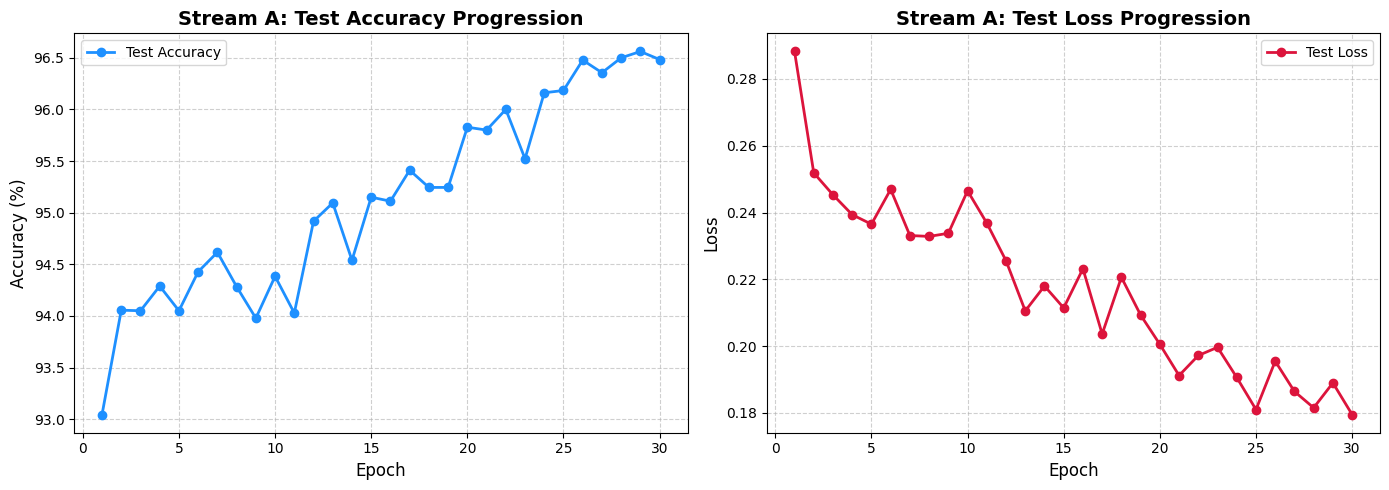

In [11]:
# Create a wide canvas for two charts side-by-side
plt.figure(figsize=(14, 5))

# Chart 1: The Accuracy Curve
plt.subplot(1, 2, 1)
plt.plot(epochs_found, [acc * 100 for acc in history_acc], marker='o', color='dodgerblue', linewidth=2, label='Test Accuracy')
plt.title('Stream A: Test Accuracy Progression', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Chart 2: The Loss Curve (The "U-Shape" or "Flatline" checker)
plt.subplot(1, 2, 2)
plt.plot(epochs_found, history_loss, marker='o', color='crimson', linewidth=2, label='Test Loss')
plt.title('Stream A: Test Loss Progression', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

In [20]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from tqdm import tqdm

# ==========================================
# 1. LOAD THE CHAMPION MODEL
# ==========================================
# Change this to your best epoch file based on the graphs you just generated!
best_model_path = 'convnext_v2_epoch_30.pth' 

print(f"Loading champion model from: {best_model_path}...")
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval() # Pencils down! No dropout.

# ==========================================
# 2. COLLECT PROBABILITIES & PREDICTIONS
# ==========================================
all_probs = []
all_preds = []
all_labels = []

print("\nRunning Final Deep Evaluation on Test Set...")
test_bar = tqdm(test_loader, desc="Calculating Metrics", leave=True)

with torch.no_grad():
    for inputs, labels in test_bar:
        inputs, labels = inputs.to(device), labels.to(device)
        
        logits = model(inputs)
        probs = F.softmax(logits, dim=1) # Convert math to % confidence
        _, predicted = torch.max(logits, 1) # Get the final guess
        
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
all_preds = np.array(all_preds)

Loading champion model from: convnext_v2_epoch_30.pth...

Running Final Deep Evaluation on Test Set...


Calculating Metrics: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 563/563 [08:09<00:00,  1.15it/s]



FINAL CLASSIFICATION REPORT
              precision    recall  f1-score   support

   colon_aca     0.9866    0.9825    0.9846      3601
     colon_n     0.9862    0.9870    0.9866      3616
    lung_aca     0.9154    0.9408    0.9279      3612
      lung_n     0.9950    0.9961    0.9955      3576
    lung_scc     0.9420    0.9179    0.9298      3595

    accuracy                         0.9648     18000
   macro avg     0.9650    0.9649    0.9649     18000
weighted avg     0.9650    0.9648    0.9648     18000



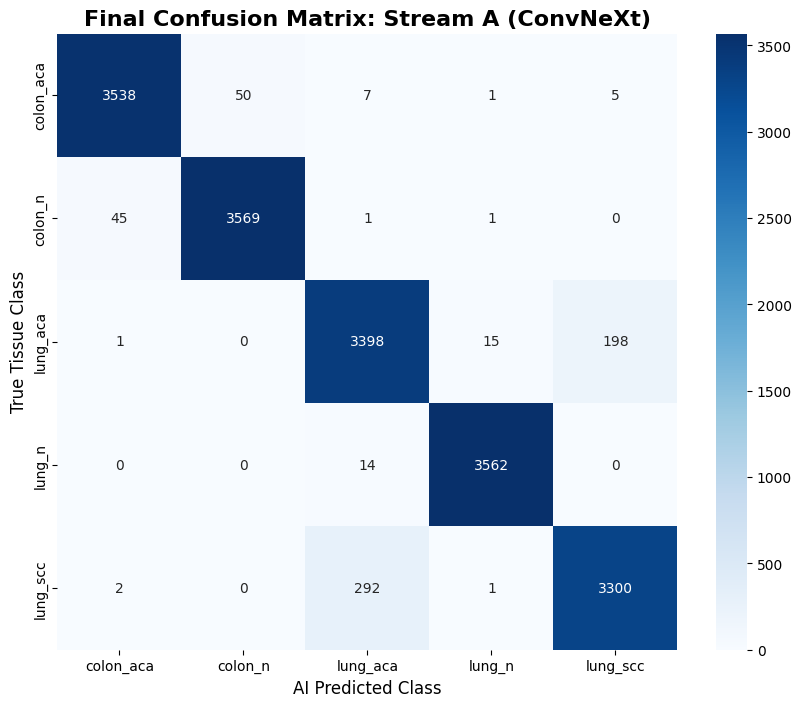

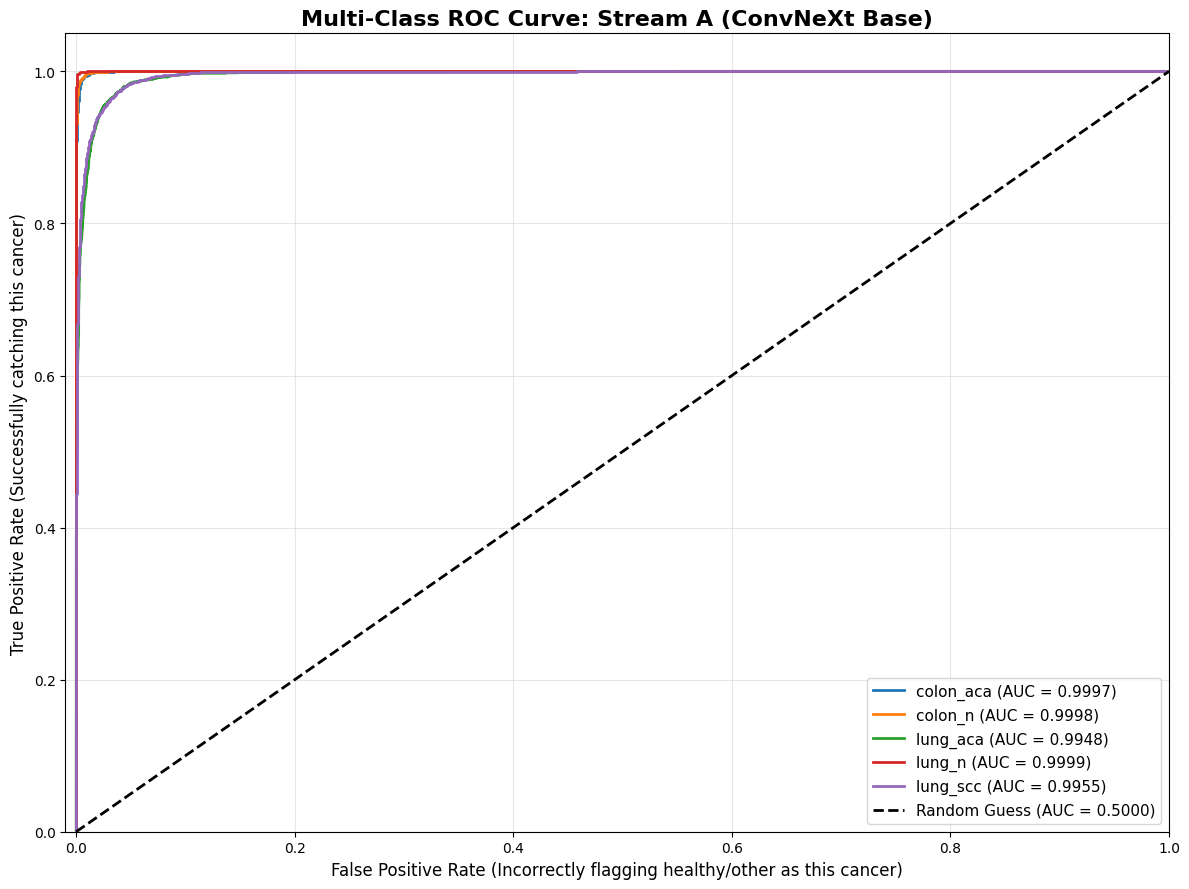

In [21]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns

# THE FIX: Manually tell it the names of the 5 folders!
class_names = ['colon_aca', 'colon_n', 'lung_aca', 'lung_n', 'lung_scc']

# ==========================================
# 3. TEXT REPORT: CLASSIFICATION REPORT
# ==========================================
print("\n" + "="*50)
print("FINAL CLASSIFICATION REPORT")
print("="*50)
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

# ==========================================
# 4. VISUAL 1: THE CONFUSION MATRIX
# ==========================================
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Final Confusion Matrix: Stream A (ConvNeXt)', fontsize=16, fontweight='bold')
plt.ylabel('True Tissue Class', fontsize=12)
plt.xlabel('AI Predicted Class', fontsize=12)
plt.show()

# ==========================================
# 5. VISUAL 2: MULTI-CLASS ROC-AUC CURVE
# ==========================================
# Binarize labels for ROC math
num_classes = len(class_names)
binarized_labels = label_binarize(all_labels, classes=range(num_classes))

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(binarized_labels[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(12, 9))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'] # Professional color palette

for i, color in zip(range(num_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.4f})')

# The 50/50 "Useless Model" baseline
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess (AUC = 0.5000)')

plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Incorrectly flagging healthy/other as this cancer)', fontsize=12)
plt.ylabel('True Positive Rate (Successfully catching this cancer)', fontsize=12)
plt.title('Multi-Class ROC Curve: Stream A (ConvNeXt Base)', fontsize=16, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()